### **Topics**
- Type of trees
- DecisionTreeClassifier
- RandomForestClassifier (equal weighted per tree)
- Models with 'estimator'
- AdaBoostClassifier (Acturate tree weighted more)
- ccp_alphas - fine-tuning
#
---

### **Type of trees - Core tree algorithms:**

##### **Decision Tree**

Recursively splits data by finding the feature+threshold that best separates classes (using Gini impurity or information gain for classification; MSE for regression). Grows until a stopping criterion (max depth, min samples) is hit. Highly interpretable — you can visualize and follow the logic. Main weakness: high variance; small data changes produce very different trees.

##### **Random Forest - ensemble**

Trains N trees, each on a bootstrapped sample of data and a random subset of features at each split. Predictions are aggregated by majority vote (classification) or average (regression). The randomness decorrelates the trees, reducing variance without much bias increase. Robust and requires little tuning, but loses the interpretability of a single tree.

##### **Gradient Boosted Trees - boosting**

Builds trees sequentially. Each new tree fits the **residual errors** of the ensemble so far (technically, the negative gradient of the loss function). Combines weak learners into a strong one. More sensitive to hyperparameters than Random Forest but generally achieves better accuracy on tabular data.

**XGBoost** adds L1/L2 regularization, handles sparse data, and uses second-order gradients for faster convergence.

**LightGBM** grows trees **leaf-wise** (deepest leaf first) instead of level-wise, and bins continuous features into histograms — much faster on large datasets.

**CatBoost** uses **ordered boosting** (avoids target leakage during training) and encodes categoricals natively using target statistics.

**When to use what:**

| Scenario | Recommended |
|---|---|
| Need to explain decisions | Decision Tree |
| Robust baseline, little tuning | Random Forest |
| Max accuracy on tabular data | XGBoost / LightGBM |
| Large dataset, speed matters | LightGBM |
| Lots of categorical features | CatBoost |

### **DecisionTreeClassifier**

Accuracy score: 0.9778


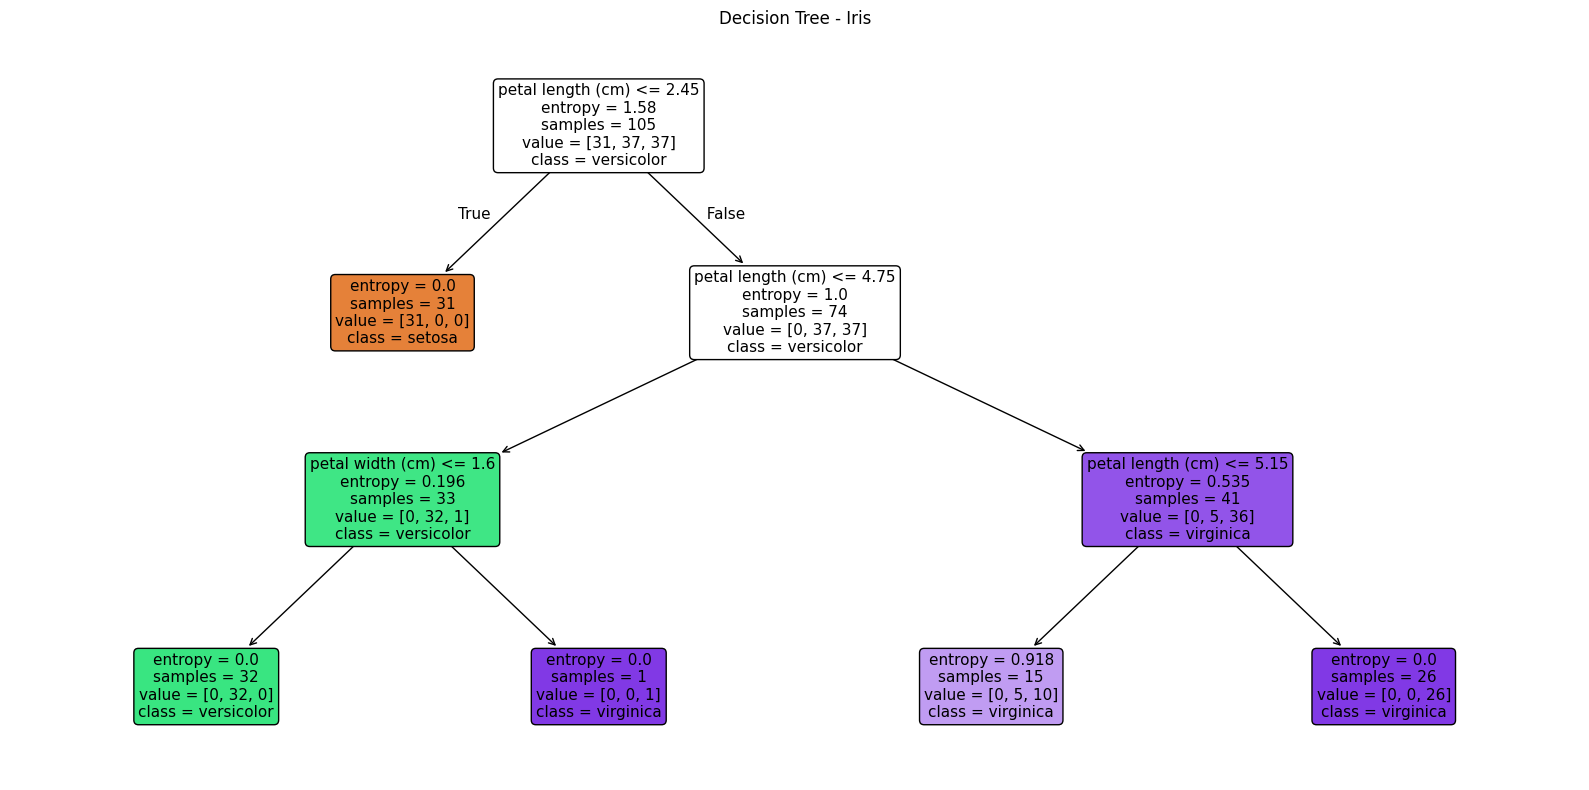

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load & train
X, y = load_iris(return_X_y=True)
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy score: {accuracy:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree,
          feature_names=iris.feature_names,  # column names
          class_names=iris.target_names,     # setosa, versicolor, virginica
          filled=True,                       # color nodes by class
          rounded=True,                      # rounded box corners
          fontsize=11,
          ax=ax)

plt.title('Decision Tree - Iris')
plt.tight_layout()
plt.show()

### **RandomForestClassifier - Majority vote**

Accuracy score: 1.0000


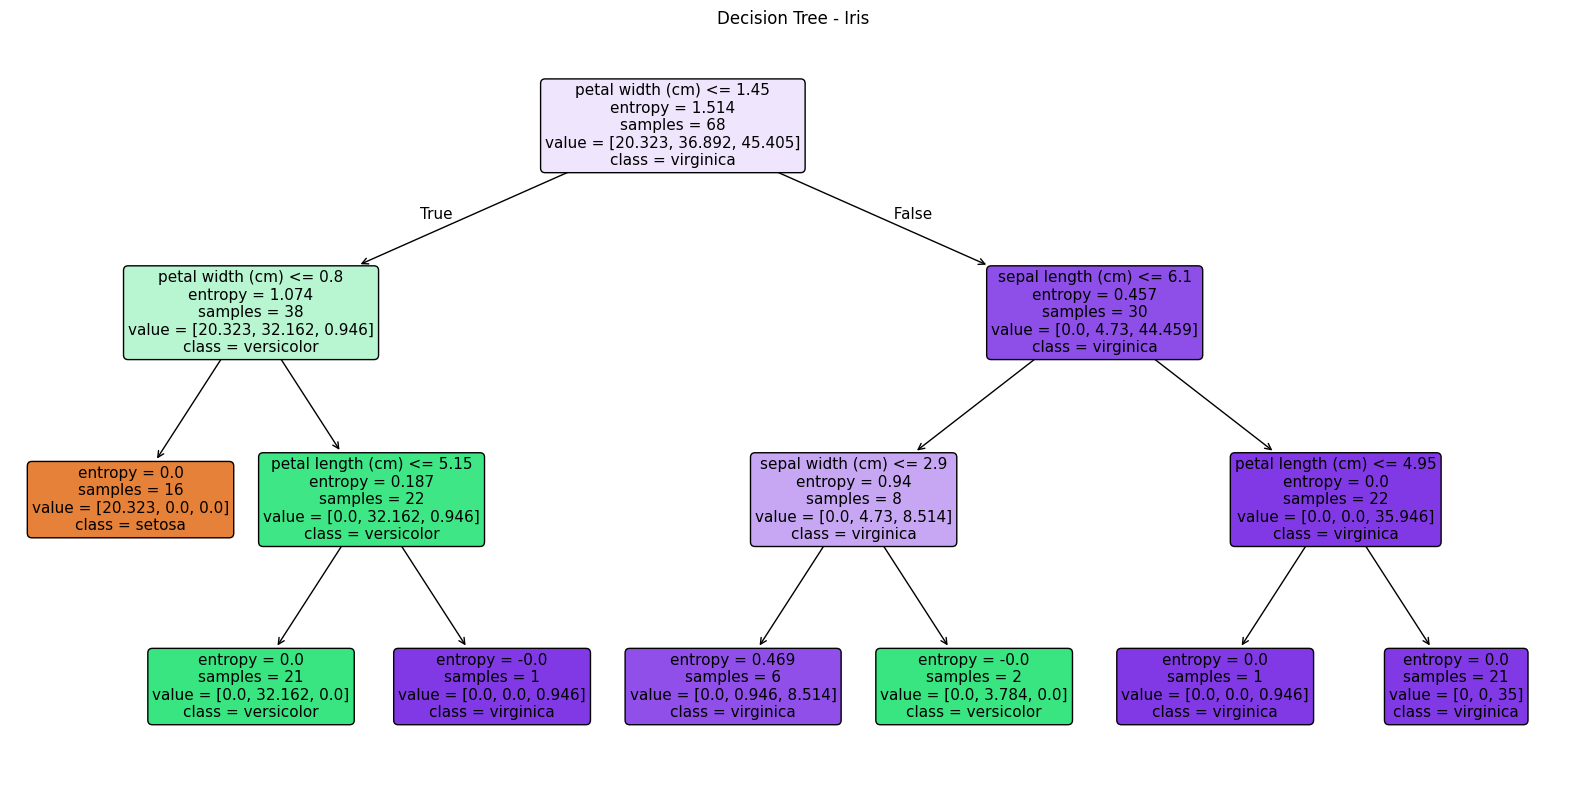

In [12]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load & train
X, y = load_iris(return_X_y=True)
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

tree = RandomForestClassifier(n_estimators=20, criterion='entropy',max_depth=3, 
                              n_jobs=-1, class_weight='balanced', random_state=42)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy score: {accuracy:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

single_tree = tree.estimators_[0]
plot_tree(single_tree,
          feature_names=iris.feature_names,  # column names
          class_names=iris.target_names,     # setosa, versicolor, virginica
          filled=True,                       # color nodes by class
          rounded=True,                      # rounded box corners
          fontsize=11,
          ax=ax)

plt.title('Decision Tree - Iris')
plt.tight_layout()
plt.show()

### **How does RandomForestClassifier work?**
Random Forest combines trees by **majority vote** (not averaging probabilities in the basic sense):


**Each tree votes for a class**
```
Sample: [5.1, 3.5, 1.4, 0.2]

Tree 1  → setosa
Tree 2  → setosa
Tree 3  → versicolor
Tree 4  → setosa
Tree 5  → setosa

Vote count: setosa=4, versicolor=1
Final prediction → setosa  ← majority wins
```


**With `predict_proba()` — averages probabilities**
```
Tree 1 → [0.9, 0.1, 0.0]
Tree 2 → [0.8, 0.2, 0.0]
Tree 3 → [0.6, 0.4, 0.0]
Tree 4 → [1.0, 0.0, 0.0]
Tree 5 → [0.7, 0.3, 0.0]

Average → [0.8, 0.2, 0.0]  ← mean across all trees
```



**How it differs from AdaBoost**

| | RandomForest | AdaBoost |
|---|---|---|
| Trees built | Independently (parallel) | Sequentially (each fixes previous) |
| Voting | Equal weight — every tree counts the same | Weighted — accurate trees count more |
| Each tree trained on | Random bootstrap sample + random features | Full data with reweighted samples |



**Why averaging helps**

Each tree makes different errors because they're trained on different random subsets of data and features. When you average many uncorrelated trees, the random errors cancel out — leaving only the signal. This is called **variance reduction**.
#
---

### **Model with "estimator"**

These sklearn ensemble models use `estimator` (singular) as a parameter — it sets the **base learner**:

```python
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Bagging
BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100)

# AdaBoost
AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100)
```

| Model | `estimator=` | Why |
|---|---|---|
| `BaggingClassifier` | any model | you choose the base learner |
| `AdaBoostClassifier` | any model (default: DecisionTree depth=1) | you can swap it out |
| `RandomForestClassifier` | ❌ no `estimator=` | always uses DecisionTree, not configurable |
| `GradientBoostingClassifier` | ❌ no `estimator=` | always uses DecisionTree internally |
| `StackingClassifier` | `estimators=` (plural, list) | list of different models to stack |

**Rule of thumb:** if the model lets you swap the base learner → `estimator=`. If the base learner is fixed internally → no `estimator=` parameter.
#
---

### **AdaBoostClassifier**

Accuracy      : 1.00
Num estimators: 50
Classes       : [0 1 2]


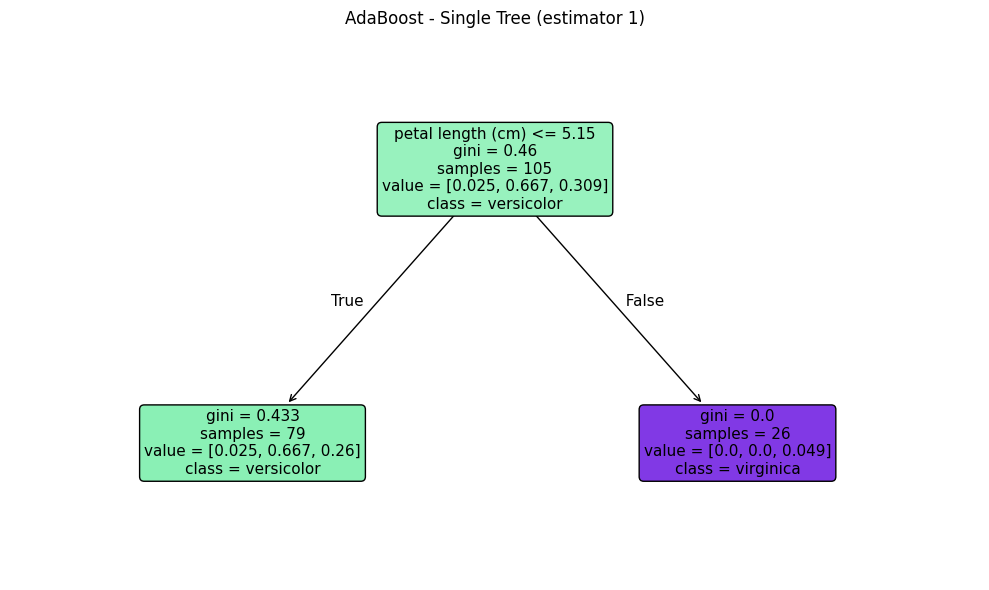

In [13]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # weak learner (stump)
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

print(f'Accuracy      : {accuracy_score(y_test, y_pred):.2f}')
print(f'Num estimators: {len(ada.estimators_)}')
print(f'Classes       : {ada.classes_}')

single_tree2 = ada.estimators_[49]

fig, ax = plt.subplots(figsize=(10, 6))  # ← create new fig and ax
plot_tree(single_tree2,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=11,
          ax=ax)

plt.title('AdaBoost - Single Tree (estimator 1)')
plt.tight_layout()
plt.show()

### **How does AdaBoostClassifier work:**

Here's how it works step by step:

**Round 1 — all samples start with equal weight**
```
Sample:   [s1,  s2,  s3,  s4,  s5]
Weight:   [0.2, 0.2, 0.2, 0.2, 0.2]  ← equal

Tree 1 predicts → gets s3, s5 wrong
```

**Round 2 — wrong samples get higher weight**
```
Sample:   [s1,  s2,  s3,  s4,  s5]
Weight:   [0.1, 0.1, 0.4, 0.1, 0.4]  ← s3, s5 boosted

Tree 2 now focuses more on s3 and s5
```

**Round 3 — new mistakes get boosted again**
```
Tree 2 gets s1, s3 wrong → their weights increase again
Tree 3 focuses on those ...
```

---

**The key idea**

Each new tree doesn't see the raw data — it sees data where hard samples feel "heavier." The tree is forced to pay more attention to the points previous trees kept getting wrong.

At the end, all trees vote, but **better trees get more voting power** (weighted by their accuracy):

```
Final prediction = Σ (tree_weight × tree_prediction)

Tree 1 (70% accurate) → weight = 0.85
Tree 2 (60% accurate) → weight = 0.41
Tree 3 (90% accurate) → weight = 2.20  ← gets more say
```

---

**Why this differs from XGBoost**

AdaBoost reweights the **samples** → harder samples matter more.

XGBoost fits the next tree to the **residual errors** (gradient of the loss) → directly minimizes how wrong the prediction was, not just which samples were misclassified.

### **ccp_alphas: cost complexity pruning alpha**

`ccp_alpha` stands for **Cost-Complexity Pruning Alpha**.

It's a penalty parameter that controls how aggressively a decision tree is pruned after it's grown. The "alpha" (α) comes from this formula:

```
R_α(T) = R(T) + α × |T|
```

- `R(T)` = misclassification rate of the tree (wrong predictions / total samples) - the fraction of training samples the tree gets
- `|T|` = number of leaves (complexity)
- `α` = how much you penalize each extra leaf

The tree keeps a branch only if its accuracy gain justifies the complexity cost. Higher α = bigger penalty for complexity = more branches get cut = simpler tree.

---

**Intuitively:**

| alpha | Meaning |
|---|---|
| `0` | No penalty — grow full tree, likely overfit |
| small | Trim only the weakest, least useful branches |
| medium | Balanced tree — usually best generalization |
| large | Aggressively pruned — may underfit |

---

**In one sentence:** `ccp_alpha` is a knob — turn it up to make the tree simpler, turn it down to let it grow more complex. Your job is to find the value where it generalizes best to unseen data.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# Get all effective alphas during pruning path
clf = DecisionTreeClassifier()
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas  # array of alpha values

# Train a tree for each alpha
trees = []
cv_scores = []
train_scores = []
test_scores = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    tn_scores = cross_val_score(clf, X_train, y_train, cv=5)
    tt_socres = clf.fit(X_train, y_train).score(X_test, y_test)
    train_scores.append(tn_scores.mean())
    test_scores.append(tt_socres)
    trees.append(clf)

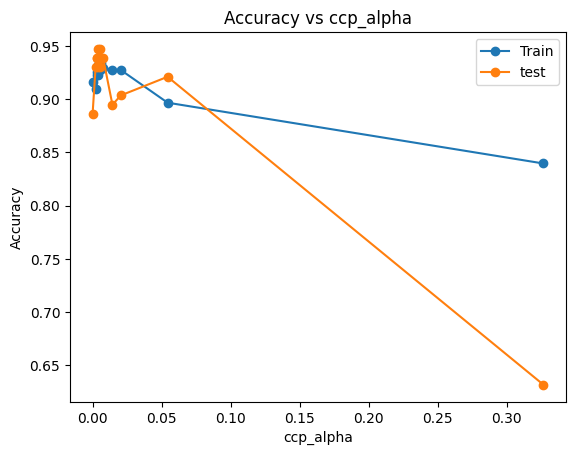

In [35]:
import matplotlib.pyplot as plt

plt.plot(ccp_alphas, train_scores, label="Train", marker="o")
plt.plot(ccp_alphas, test_scores,   label="test", marker="o")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy vs ccp_alpha")
plt.show()